# FPGA-Accelerated Speaker Recognition — FINN Synthesis

End-to-end: train compact QAT models with Brevitas to deploy via FINN on KV260.


## Training Strategy

| Stage | LR | Epochs | ES Patience | Scheduler |
|-------|-----|--------|-------------|-----------|
| **Float** | 1e-3 | 150 | 20 | ReduceLR(0.5, pat=10, min=1e-6) |
| **QAT-8** | 1e-4 | 40 | 10 | — (fine-tune from float) |
| **QAT-4** | 5e-4 | 100 | 10 | — (fine-tune from float) |


---
## 0. Environment Setup

In [1]:
import torch
import numpy as np
import onnx

print(f'PyTorch : {torch.__version__}')
print(f'NumPy   : {np.__version__}')
print(f'ONNX    : {onnx.__version__}')
print(f'Device  : {torch.device("cuda" if torch.cuda.is_available() else "cpu")}')

PyTorch : 1.13.1+cu116
NumPy   : 1.26.4
ONNX    : 1.17.0
Device  : cpu


### Core Imports and Custom Quantizers

In [2]:
import os, json, pickle, copy, time, subprocess
from pathlib import Path

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import brevitas.nn as qnn
from brevitas.quant import (
    Int8ActPerTensorFloat, Int8WeightPerTensorFloat, Uint8ActPerTensorFloat,
)
from brevitas.export import export_qonnx

class Int4WeightPerTensorFloat(Int8WeightPerTensorFloat):
    bit_width = 4

import librosa, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

RANDOM_SEED = 55
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(RANDOM_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
BASE_DIR          = Path('.')
MFCC_DATASETS_DIR = BASE_DIR / 'MFCC_datasets'
MODELS_DIR        = BASE_DIR / 'trained_models'
ONNX_DIR          = BASE_DIR / 'onnx_exports'
FINN_BUILD_DIR    = BASE_DIR / 'finn_build'
HISTORY_DIR       = BASE_DIR / 'training_history'
for d in [MODELS_DIR, ONNX_DIR, FINN_BUILD_DIR, HISTORY_DIR]:
    d.mkdir(parents=True, exist_ok=True)

---
## 1. Dataset Preparation

In [4]:
META_PATH = MFCC_DATASETS_DIR / 'metadata.json'
with open(META_PATH, 'r') as f:
    meta = json.load(f)
NUM_CLASSES   = meta['num_classes']
N_MFCC        = meta['N_MFCC']
MFCC_FRAMES   = meta['MFCC_FRAMES']
SAMPLING_FREQ = meta['SAMPLING_FREQ']
HOP_LENGTH    = meta.get('HOP_LENGTH', 2250)
subfolders    = meta['subfolders']

assert MFCC_FRAMES == 64 and HOP_LENGTH == 2250, (
    f'Dataset incompatible: MFCC_FRAMES={MFCC_FRAMES}, HOP_LENGTH={HOP_LENGTH}. '
    'Run MFCC_dataset_generation.ipynb with hop_length=2250.'
)

assert N_MFCC == 16, (
    f'\n[ERROR] Dataset uses N_MFCC={N_MFCC} but architecture requires N_MFCC=16.\n'
    f'  MaxPool(2,4) on H=4 requires N_MFCC divisible by 8.\n'
    f'  N_MFCC=20 caused StreamingMaxPool pH=H=5 deadlock in FINN hardware.\n'
    'Solution: run MFCC_dataset_generation.ipynb with N_MFCC=16.'
)

print(f'Classes: {NUM_CLASSES} {subfolders}')
print(f'Input: ({N_MFCC}, {MFCC_FRAMES}, 2), hop={HOP_LENGTH}')
print('[OK] BRAM-Opt v2 verified')

Classes: 10 ['f0001', 'f0002', 'f0003', 'f0004', 'f0005', 'm0001', 'm0002', 'm0003', 'm0004', 'm0005']
Input: (16, 64, 2), hop=2250
[OK] BRAM-Opt v2 verified


In [5]:
import tensorflow as tf
with open(MFCC_DATASETS_DIR / 'element_spec.pkl', 'rb') as f:
    specs = pickle.load(f)
def batched_tf_to_numpy(path, spec):
    ds = tf.data.Dataset.load(str(path), element_spec=spec)
    X, y = [], []
    for xb, yb in ds:
        X.append(xb.numpy()); y.append(yb.numpy())
    return np.concatenate(X), np.concatenate(y)
print('Loading splits...')
X_train, y_train = batched_tf_to_numpy(MFCC_DATASETS_DIR/'train_batches', specs['train'])
X_val, y_val     = batched_tf_to_numpy(MFCC_DATASETS_DIR/'validation_batches', specs['validation'])
X_test, y_test   = batched_tf_to_numpy(MFCC_DATASETS_DIR/'test_batches', specs['test'])
y_train, y_val, y_test = y_train.astype(np.int64), y_val.astype(np.int64), y_test.astype(np.int64)
print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

2026-04-04 20:09:30.025670: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-04 20:09:30.046745: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Loading splits...
Train: (2298, 16, 64, 2), Val: (492, 16, 64, 2), Test: (493, 16, 64, 2)


2026-04-04 20:09:30.945254: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-04 20:09:30.972024: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### DataLoaders

In [6]:
POOL_KERNELS = [(2,2), (2,4), (2,4)]

def numpy_to_loader(X, y, batch_size=32, shuffle=True):
    X_t = torch.from_numpy(X).permute(0, 3, 1, 2).contiguous()
    _, _, h, w = X_t.shape
    h_div, w_div = 1, 1
    for ph, pw in POOL_KERNELS:
        h_div *= ph; w_div *= pw
    assert h % h_div == 0 and w % w_div == 0, \
        f'Input ({h},{w}) not divisible by pool chain ({h_div},{w_div})'
    return DataLoader(TensorDataset(X_t, torch.from_numpy(y).long()),
                      batch_size=batch_size, shuffle=shuffle, num_workers=0, pin_memory=True)

BATCH_SIZE = 32
train_loader = numpy_to_loader(X_train, y_train, BATCH_SIZE, shuffle=True)
val_loader   = numpy_to_loader(X_val, y_val, BATCH_SIZE, shuffle=False)
test_loader  = numpy_to_loader(X_test, y_test, BATCH_SIZE, shuffle=False)

xb, _ = next(iter(train_loader))
h, w = xb.shape[2], xb.shape[3]
print(f'Batch: {xb.shape}')
print(f'Pool trace: ({h},{w})', end='')
for ph, pw in POOL_KERNELS:
    h, w = h//ph, w//pw
    print(f' -> ({h},{w})', end='')
print(f'\nFlattened: 8 x {h} x {w} = {8*h*w}')

Batch: torch.Size([32, 2, 16, 64])
Pool trace: (16,64) -> (8,32) -> (4,8) -> (2,2)
Flattened: 8 x 2 x 2 = 32


---
## 2. Model Definitions

In [7]:
class SpeakerCNN_Float(nn.Module):
    """BRAM-Opt v2 float baseline. All layers <= 576 params."""
    def __init__(self, num_classes, input_channels=2, n_mfcc=20, n_frames=64):
        super().__init__()
        self.conv1 = nn.Conv2d(input_channels, 8, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(8); self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d((2,2))

        self.conv2 = nn.Conv2d(8, 8, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(8); self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d((2,4))

        self.conv3 = nn.Conv2d(8, 8, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(8); self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d((2,4))

        with torch.no_grad():
            d = torch.zeros(1, input_channels, n_mfcc, n_frames)
            d = self.pool1(self.relu1(self.bn1(self.conv1(d))))
            d = self.pool2(self.relu2(self.bn2(self.conv2(d))))
            d = self.pool3(self.relu3(self.bn3(self.conv3(d))))
            flat_size = d.view(1,-1).shape[1]

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(flat_size, 16); self.relu4 = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(16, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu3(self.bn3(self.conv3(x))))
        x = self.flatten(x)
        x = self.dropout(self.relu4(self.fc1(x)))
        return self.fc2(x)

print('Float model defined.')

Float model defined.


### Brevitas Quantized Model

In [8]:
import brevitas.config as brev_cfg
brev_cfg.IGNORE_MISSING_KEYS = True

def get_wq(bw):
    if bw == 8: return Int8WeightPerTensorFloat
    elif bw == 4: return Int4WeightPerTensorFloat
    else: raise ValueError(bw)

class SpeakerCNN_Quant(nn.Module):
    """BRAM-Opt v2 Brevitas model for FINN deployment."""
    def __init__(self, num_classes, weight_bits=8, act_bits=8,
                 input_channels=2, n_mfcc=20, n_frames=64):
        super().__init__()
        wq = get_wq(weight_bits)
        aq = Uint8ActPerTensorFloat
        iq = Int8ActPerTensorFloat

        self.inp_quant = qnn.QuantIdentity(act_quant=iq, return_quant_tensor=True)
        self.conv1 = qnn.QuantConv2d(input_channels, 8, 3, padding=1,
            weight_bit_width=weight_bits, weight_quant=wq, bias=True)
        self.bn1 = nn.BatchNorm2d(8)
        self.relu1 = qnn.QuantReLU(act_quant=aq, return_quant_tensor=True)
        self.pool1 = nn.MaxPool2d((2,2))

        self.conv2 = qnn.QuantConv2d(8, 8, 3, padding=1,
            weight_bit_width=weight_bits, weight_quant=wq, bias=True)
        self.bn2 = nn.BatchNorm2d(8)
        self.relu2 = qnn.QuantReLU(act_quant=aq, return_quant_tensor=True)
        self.pool2 = nn.MaxPool2d((2,4))

        self.conv3 = qnn.QuantConv2d(8, 8, 3, padding=1,
            weight_bit_width=weight_bits, weight_quant=wq, bias=True)
        self.bn3 = nn.BatchNorm2d(8)
        self.relu3 = qnn.QuantReLU(act_quant=aq, return_quant_tensor=True)
        self.pool3 = nn.MaxPool2d((2,4))

        with torch.no_grad():
            d = torch.zeros(1, input_channels, n_mfcc, n_frames)
            d = self.pool1(self.bn1(self.conv1(d)))
            d = self.pool2(self.bn2(self.conv2(d)))
            d = self.pool3(self.bn3(self.conv3(d)))
            flat_size = d.view(1,-1).shape[1]

        self.flatten = nn.Flatten()
        self.fc1 = qnn.QuantLinear(flat_size, 16, bias=True,
            weight_bit_width=weight_bits, weight_quant=wq)
        self.relu4 = qnn.QuantReLU(act_quant=aq, return_quant_tensor=True)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = qnn.QuantLinear(16, num_classes, bias=True,
            weight_bit_width=weight_bits, weight_quant=wq)

    def forward(self, x):
        x = self.inp_quant(x)
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu3(self.bn3(self.conv3(x))))
        x = self.flatten(x)
        x = self.dropout(self.relu4(self.fc1(x)))
        return self.fc2(x)


def transfer_float_weights(float_model, qat_model):
    """Transfer compatible weights from float model to QAT model."""
    float_sd = float_model.state_dict()
    qat_sd = qat_model.state_dict()
    n_transferred = 0
    for key in qat_sd:
        if key in float_sd and qat_sd[key].shape == float_sd[key].shape:
            qat_sd[key] = float_sd[key]
            n_transferred += 1
    qat_model.load_state_dict(qat_sd)
    print(f'  Transferred {n_transferred}/{len(qat_sd)} parameters from float model.')

print('Quantized model defined.')

Quantized model defined.


---
## 3. Training Infrastructure

In [9]:
class EarlyStopping:
    def __init__(self, patience=15, min_delta=1e-4):
        self.patience, self.min_delta = patience, min_delta
        self.best_loss, self.counter, self.best_state, self.should_stop = float('inf'), 0, None, False
    def step(self, vl, model):
        if vl < self.best_loss - self.min_delta:
            self.best_loss, self.counter = vl, 0
            self.best_state = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            if self.counter >= self.patience: self.should_stop = True
    def restore(self, model):
        if self.best_state:
            model.load_state_dict(self.best_state)
            print(f'  Restored best (val_loss={self.best_loss:.4f})')

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train(); rl, c, t = 0., 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(); logits = model(xb); loss = criterion(logits, yb)
        loss.backward(); optimizer.step()
        rl += loss.item()*xb.size(0); c += (logits.argmax(1)==yb).sum().item(); t += xb.size(0)
    return rl/t, c/t

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval(); rl, c, t = 0., 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb); loss = criterion(logits, yb)
        rl += loss.item()*xb.size(0); c += (logits.argmax(1)==yb).sum().item(); t += xb.size(0)
    return rl/t, c/t

def train_model(model, name, train_loader, val_loader, device,
                epochs=150, lr=1e-3, patience=20, use_scheduler=True):
    ckpt = MODELS_DIR / f'{name}.pt'
    hist_file = HISTORY_DIR / f'{name}_history.json'
    if ckpt.exists():
        print(f'[{name}] Checkpoint found — loading.')
        model.load_state_dict(torch.load(ckpt, map_location=device), strict=False)
        model.to(device)
        return json.load(open(hist_file)) if hist_file.exists() else {}
    print(f'[{name}] Training: epochs={epochs}, lr={lr}, patience={patience}, scheduler={use_scheduler}')
    model.to(device)
    crit = nn.CrossEntropyLoss()
    opt = optim.Adam(model.parameters(), lr=lr)
    sched = None
    if use_scheduler:
        sched = optim.lr_scheduler.ReduceLROnPlateau(
            opt, 'min', factor=0.5, patience=10, min_lr=1e-6)
    es = EarlyStopping(patience=patience)
    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    for ep in range(1, epochs+1):
        t0 = time.time()
        tl, ta = train_one_epoch(model, train_loader, crit, opt, device)
        vl, va = evaluate(model, val_loader, crit, device)
        if sched: sched.step(vl)
        es.step(vl, model)
        for k, v in zip(history, [tl, vl, ta, va]): history[k].append(v)
        if ep % 5 == 0 or ep == 1 or es.should_stop:
            current_lr = opt.param_groups[0]['lr']
            print(f'  {ep:3d}/{epochs} tl={tl:.4f} vl={vl:.4f} ta={ta:.3f} va={va:.3f} lr={current_lr:.1e} [{time.time()-t0:.1f}s]')
        if es.should_stop: print(f'  Early stop at {ep}.'); break
    es.restore(model)
    torch.save(model.state_dict(), ckpt)
    json.dump(history, open(hist_file, 'w'))
    print(f'  Saved: {ckpt}')
    return history

def plot_history(h, title=''):
    if not h: return
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
    a1.plot(h['train_loss'], label='Train'); a1.plot(h['val_loss'], label='Val')
    a1.set_title('Loss'); a1.set_xlabel('Epoch'); a1.legend()
    a2.plot(h['train_acc'], label='Train'); a2.plot(h['val_acc'], label='Val')
    a2.set_title('Accuracy'); a2.set_xlabel('Epoch'); a2.set_ylim([0,1]); a2.legend()
    fig.suptitle(title); plt.tight_layout(); plt.show()

def full_eval(model, loader, device, names=None, title=''):
    model.eval(); ap, al = [], []
    with torch.no_grad():
        for xb, yb in loader:
            ap.extend(model(xb.to(device)).argmax(1).cpu().numpy()); al.extend(yb.numpy())
    cm = confusion_matrix(al, ap)
    if not names: names = [str(i) for i in range(cm.shape[0])]
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=names, yticklabels=names)
    plt.xlabel('Pred'); plt.ylabel('True'); plt.title(title); plt.tight_layout(); plt.show()
    print(classification_report(al, ap, target_names=names))
    return np.mean(np.array(ap)==np.array(al))

print('Training utilities ready.')

Training utilities ready.


---
## 4. Train Float Baseline

Adam LR=1e-3, ReduceLROnPlateau(factor=0.5, patience=10, min_lr=1e-6),
EarlyStopping patience=20, up to 150 epochs.

SpeakerCNN_Float(
  (conv1): Conv2d(2, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=(2, 4), stride=(2, 4), padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=(2, 4), stride=(2, 4), padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=32, out_features=16, bias=True)
  (relu4): ReLU()
  (dropout): Dropout(p=0.3,

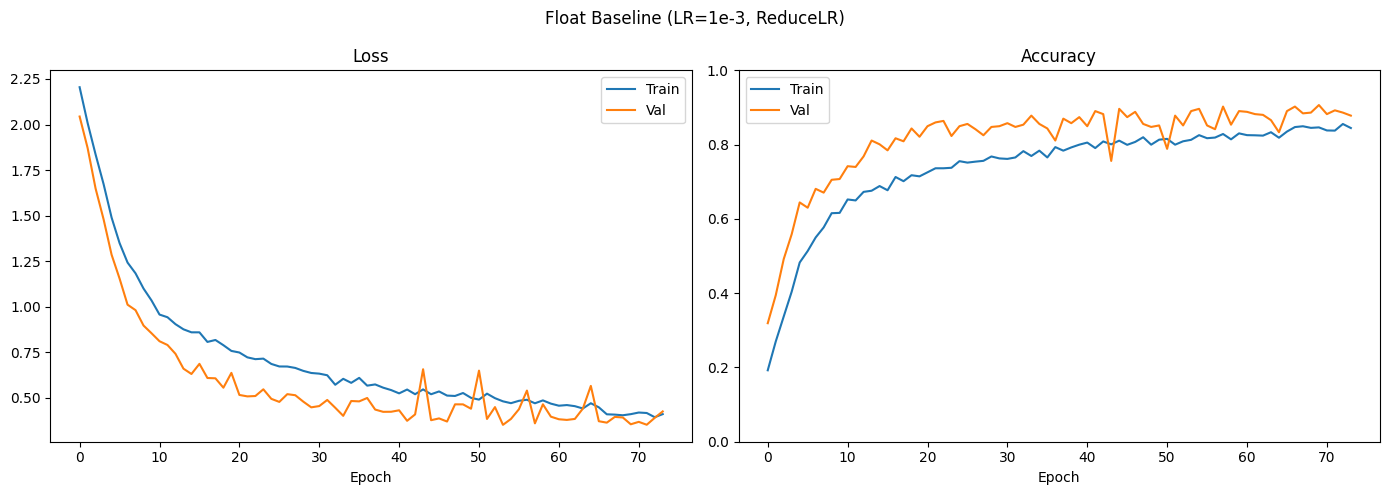

In [10]:
model_float = SpeakerCNN_Float(NUM_CLASSES, 2, N_MFCC, MFCC_FRAMES)
print(model_float)
print(f'Parameters: {sum(p.numel() for p in model_float.parameters()):,}')

hist_float = train_model(
    model_float, 'float_baseline', train_loader, val_loader, DEVICE,
    epochs=150, lr=1e-3, patience=20, use_scheduler=True
)
plot_history(hist_float, 'Float Baseline (LR=1e-3, ReduceLR)')

---
## 5. Train QAT Models (Fine-tuned from Float)

| QAT | LR | Epochs | ES Patience | Init |
|-----|-----|--------|-------------|------|
| **8-bit** | 1e-4 | 40 | 10 | Float weights |
| **4-bit** | 5e-4 | 100 | 10 | Float weights |

/usr/local/lib/python3.10/dist-packages/torch/_tensor.py:1255: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at ../c10/core/TensorImpl.h:1758.)
  return super(Tensor, self).rename(names)


Transferring float weights to QAT-8 model...
  Transferred 25/25 parameters from float model.
[qat_8bit] Training: epochs=40, lr=0.0001, patience=10, scheduler=False
    1/40 tl=0.4545 vl=0.3574 ta=0.828 va=0.888 lr=1.0e-04 [1.7s]
    5/40 tl=0.4286 vl=0.3465 ta=0.841 va=0.888 lr=1.0e-04 [1.4s]
   10/40 tl=0.4332 vl=0.3414 ta=0.841 va=0.896 lr=1.0e-04 [1.3s]
   15/40 tl=0.4307 vl=0.3363 ta=0.833 va=0.888 lr=1.0e-04 [1.3s]
   17/40 tl=0.4290 vl=0.3377 ta=0.835 va=0.896 lr=1.0e-04 [1.3s]
  Early stop at 17.
  Restored best (val_loss=0.3313)
  Saved: trained_models/qat_8bit.pt


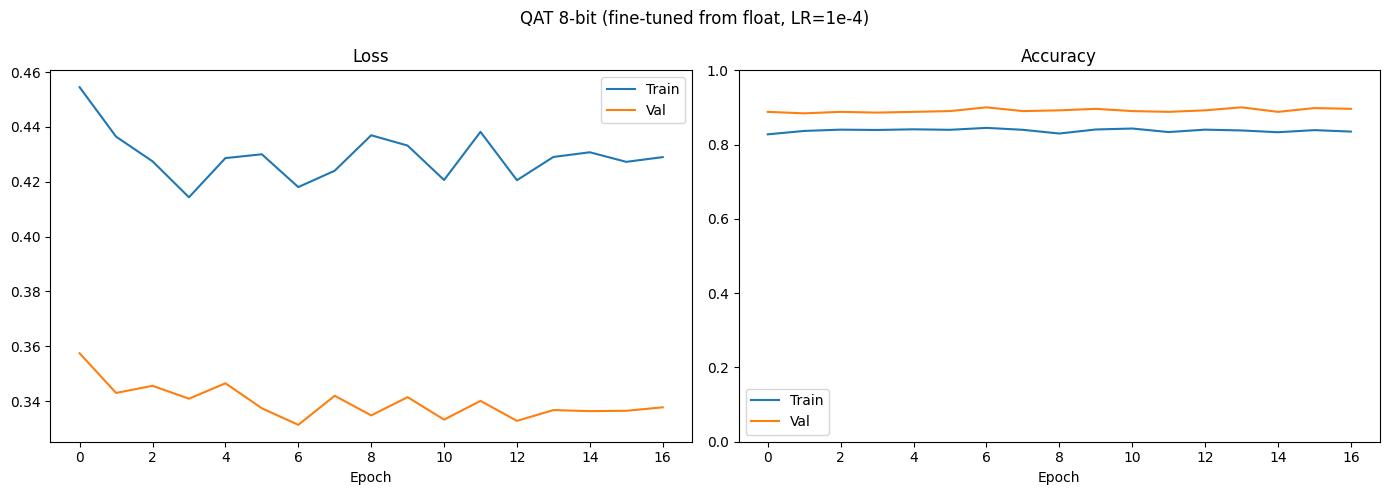

In [11]:
model_q8 = SpeakerCNN_Quant(NUM_CLASSES, weight_bits=8, act_bits=8,
    input_channels=2, n_mfcc=N_MFCC, n_frames=MFCC_FRAMES)
ckpt_q8 = MODELS_DIR / 'qat_8bit.pt'
if not ckpt_q8.exists():
    print('Transferring float weights to QAT-8 model...')
    transfer_float_weights(model_float, model_q8)
hist_q8 = train_model(
    model_q8, 'qat_8bit', train_loader, val_loader, DEVICE,
    epochs=40, lr=1e-4, patience=10, use_scheduler=False
)
plot_history(hist_q8, 'QAT 8-bit (fine-tuned from float, LR=1e-4)')

Transferring float weights to QAT-4 model...
  Transferred 25/25 parameters from float model.
[qat_4bit] Training: epochs=100, lr=0.0005, patience=10, scheduler=False
    1/100 tl=0.6129 vl=0.4084 ta=0.758 va=0.872 lr=5.0e-04 [1.1s]
    5/100 tl=0.5586 vl=0.4337 ta=0.780 va=0.874 lr=5.0e-04 [1.4s]
   10/100 tl=0.5330 vl=0.6320 ta=0.800 va=0.791 lr=5.0e-04 [1.3s]
   11/100 tl=0.5585 vl=0.4502 ta=0.788 va=0.854 lr=5.0e-04 [1.3s]
  Early stop at 11.
  Restored best (val_loss=0.4084)
  Saved: trained_models/qat_4bit.pt


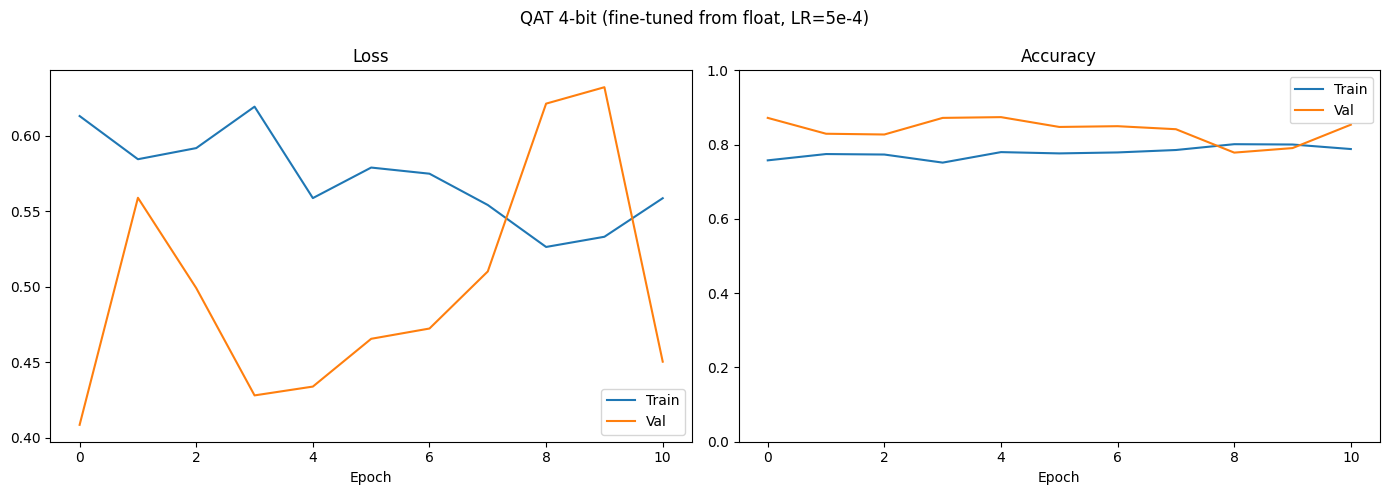

In [12]:
model_q4 = SpeakerCNN_Quant(NUM_CLASSES, weight_bits=4, act_bits=8,
    input_channels=2, n_mfcc=N_MFCC, n_frames=MFCC_FRAMES)
ckpt_q4 = MODELS_DIR / 'qat_4bit.pt'
if not ckpt_q4.exists():
    print('Transferring float weights to QAT-4 model...')
    transfer_float_weights(model_float, model_q4)
hist_q4 = train_model(
    model_q4, 'qat_4bit', train_loader, val_loader, DEVICE,
    epochs=100, lr=5e-4, patience=10, use_scheduler=False
)
plot_history(hist_q4, 'QAT 4-bit (fine-tuned from float, LR=5e-4)')

---
## 6. Test-Set Evaluation


  Float


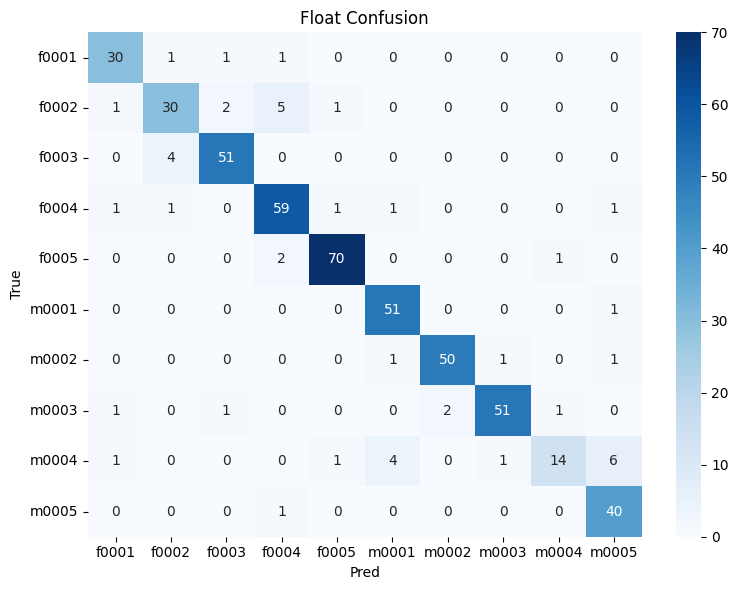

              precision    recall  f1-score   support

       f0001       0.88      0.91      0.90        33
       f0002       0.83      0.77      0.80        39
       f0003       0.93      0.93      0.93        55
       f0004       0.87      0.92      0.89        64
       f0005       0.96      0.96      0.96        73
       m0001       0.89      0.98      0.94        52
       m0002       0.96      0.94      0.95        53
       m0003       0.96      0.91      0.94        56
       m0004       0.88      0.52      0.65        27
       m0005       0.82      0.98      0.89        41

    accuracy                           0.90       493
   macro avg       0.90      0.88      0.88       493
weighted avg       0.91      0.90      0.90       493


  QAT-8


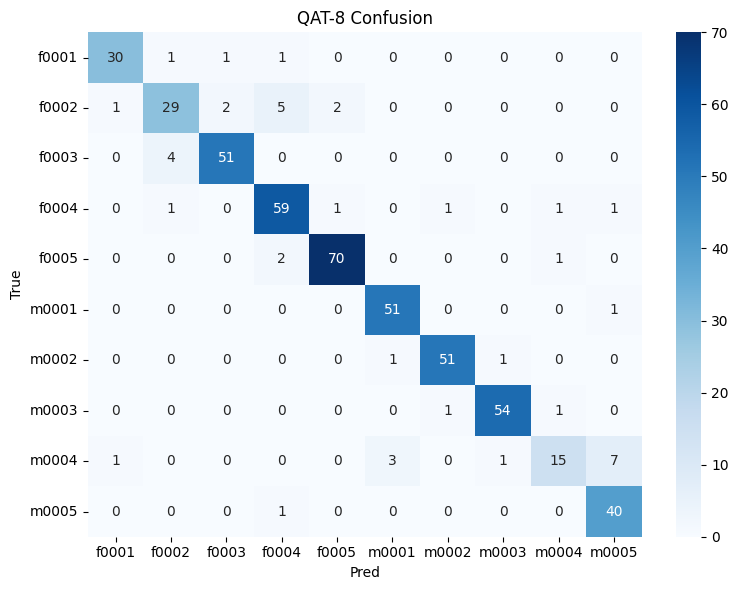

              precision    recall  f1-score   support

       f0001       0.94      0.91      0.92        33
       f0002       0.83      0.74      0.78        39
       f0003       0.94      0.93      0.94        55
       f0004       0.87      0.92      0.89        64
       f0005       0.96      0.96      0.96        73
       m0001       0.93      0.98      0.95        52
       m0002       0.96      0.96      0.96        53
       m0003       0.96      0.96      0.96        56
       m0004       0.83      0.56      0.67        27
       m0005       0.82      0.98      0.89        41

    accuracy                           0.91       493
   macro avg       0.90      0.89      0.89       493
weighted avg       0.91      0.91      0.91       493


  QAT-4


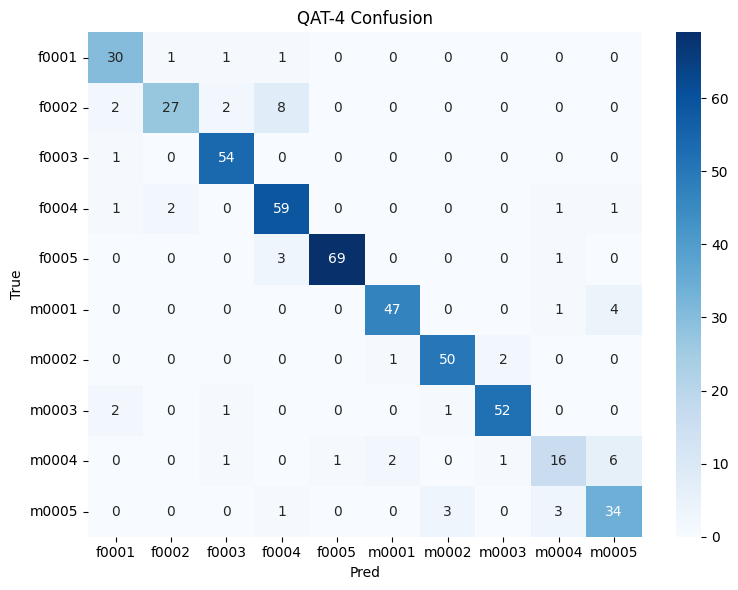

              precision    recall  f1-score   support

       f0001       0.83      0.91      0.87        33
       f0002       0.90      0.69      0.78        39
       f0003       0.92      0.98      0.95        55
       f0004       0.82      0.92      0.87        64
       f0005       0.99      0.95      0.97        73
       m0001       0.94      0.90      0.92        52
       m0002       0.93      0.94      0.93        53
       m0003       0.95      0.93      0.94        56
       m0004       0.73      0.59      0.65        27
       m0005       0.76      0.83      0.79        41

    accuracy                           0.89       493
   macro avg       0.87      0.86      0.87       493
weighted avg       0.89      0.89      0.89       493


Model                    Accuracy
  Float             : 90.47%
  QAT-8             : 91.28%
  QAT-4             : 88.84%


In [13]:
results = {}
for name, model in [('Float', model_float), ('QAT-8', model_q8), ('QAT-4', model_q4)]:
    print(f'\n{"="*50}\n  {name}\n{"="*50}')
    model.to(DEVICE)
    results[name] = full_eval(model, test_loader, DEVICE, subfolders, f'{name} Confusion')
print('\n' + '=' * 52)
print(f'{"Model":<20} {"Accuracy":>12}')
print('=' * 52)
for n, a in results.items():
    print(f'  {n:<18}: {a*100:.2f}%')
print('=' * 52)

---
## 7. ONNX Export

In [14]:
# ============================================================
# Record QUANT_SCALE for Kria deployment
# ============================================================
scales = {}
for name, mdl in [('qat_8bit', model_q8), ('qat_4bit', model_q4)]:
    scale = mdl.inp_quant.quant_act_scale().item()
    quant_scale = 1.0 / scale
    scales[name] = quant_scale
    print(f"{name}:  act_scale={scale:.8f}  →  QUANT_SCALE={quant_scale:.6f}")

# Save to file so Kria notebook can load it
import json
with open('quant_scales.json', 'w') as f:
    json.dump(scales, f, indent=2)
print("\nSaved to quant_scales.json")

qat_8bit:  act_scale=0.04447622  →  QUANT_SCALE=22.483924
qat_4bit:  act_scale=0.04332599  →  QUANT_SCALE=23.080834

Saved to quant_scales.json


In [15]:
float_onnx = ONNX_DIR / 'speaker_cnn_float.onnx'
if not float_onnx.exists():
    model_float.eval().cpu()
    torch.onnx.export(model_float, torch.randn(1,2,N_MFCC,MFCC_FRAMES), str(float_onnx),
        input_names=['input'], output_names=['output'],
        dynamic_axes={'input':{0:'batch'},'output':{0:'batch'}}, opset_version=13)
onnx.checker.check_model(onnx.load(str(float_onnx)))
print(f'Float ONNX: {float_onnx}')

Float ONNX: onnx_exports/speaker_cnn_float.onnx


In [16]:
def export_brevitas_qonnx(mdl, name):
    p = ONNX_DIR / f'speaker_cnn_{name}.onnx'
    if p.exists(): print(f'  [{name}] exists'); return p
    mdl.eval().cpu()
    from brevitas.export import export_qonnx as eq
    eq(mdl, torch.randn(1,2,N_MFCC,MFCC_FRAMES), str(p))
    onnx.checker.check_model(onnx.load(str(p)))
    print(f'  [{name}] exported'); return p

qonnx_paths = {}
for tag, m in [('qat_8bit', model_q8), ('qat_4bit', model_q4)]:
    qonnx_paths[tag] = export_brevitas_qonnx(m, tag)
print('\nAll QONNX exports done.')

  [qat_8bit] exported
  [qat_4bit] exported

All QONNX exports done.


---
## 8. FINN Synthesis

### Docker/Vivado Fixes Applied
- **`XILINX_LOCAL_USER_DATA=no`** — disables Vivado WebTalk telemetry, which crashes
  inside Docker due to `libudev` trying to enumerate host devices in a restricted `/dev`.
  Without this, Vivado crashes after successful routing but before `write_bitstream`.
- **`step_out_of_context_synthesis` removed** — this step launches a redundant Vivado
  synthesis that can OOM-kill the host on systems with <32 GB RAM. The actual resource
  numbers come from step 10 (analytical estimates) and step 16 (full implementation).
- **Vitis HLS sourced** into `os.environ` so FINN's multiprocessing workers can find it.

In [17]:
# ============================================================
# 8a. Source Vitis HLS
# ============================================================

# Source Vitis HLS into this Python process
vitis_settings = '/tools/Xilinx/Vitis_HLS/2022.2/settings64.sh'
if os.path.exists(vitis_settings):
    result = subprocess.run(
        ['bash', '-c', f'source {vitis_settings} && env'],
        capture_output=True, text=True)
    for line in result.stdout.splitlines():
        if '=' in line:
            k, _, v = line.partition('=')
            os.environ[k] = v
    print(f'vitis_hls: {subprocess.run(["which","vitis_hls"], capture_output=True, text=True).stdout.strip()}')
else:
    print(f'WARNING: {vitis_settings} not found')

os.environ['VIVADO_PATH'] = '/tools/Xilinx/Vivado/2022.2'
# HLS_PATH is needed by CompileCppSim worker processes
os.environ['HLS_PATH'] = '/tools/Xilinx/Vitis_HLS/2022.2'

vitis_hls: /tools/Xilinx/Vitis_HLS/2022.2/bin/vitis_hls


In [18]:
# ============================================================
# 8b. FINN build config
# ============================================================

FPGA_PART = 'xck26-sfvc784-2LV-c'
CLOCK_NS  = 5.0
BOARD     = 'KV260_SOM'

FINN_AVAILABLE = False
try:
    import finn.builder.build_dataflow as build
    import finn.builder.build_dataflow_config as build_cfg
    from finn.builder.build_dataflow_config import DataflowBuildConfig, ShellFlowType, VerificationStepType
    from finn.builder.build_dataflow_steps import (
        step_qonnx_to_finn, step_tidy_up, step_streamline, step_convert_to_hw,
        step_create_dataflow_partition, step_specialize_layers,
        step_target_fps_parallelization, step_apply_folding_config,
        step_minimize_bit_width, step_generate_estimate_reports,
        step_hw_codegen, step_hw_ipgen, step_set_fifo_depths,
        step_create_stitched_ip, step_measure_rtlsim_performance,
        step_make_pynq_driver, step_synthesize_bitfile, step_deployment_package
    )
    FINN_AVAILABLE = True
    BUILD_STEPS = [
        step_qonnx_to_finn,                # 1.  QONNX → FINN-ONNX
        step_tidy_up,                       # 2.  Clean up graph
        step_streamline,                    # 3.  Absorb BN, optimize arithmetic
        step_convert_to_hw,                 # 4.  Map to FINN HW operators
        step_create_dataflow_partition,     # 5.  Create single accelerator partition
        step_specialize_layers,             # 6.  Select HLS/RTL per layer
        step_target_fps_parallelization,    # 7.  Set PE/SIMD for target throughput
        step_apply_folding_config,          # 8.  Apply user folding (if any)
        step_minimize_bit_width,            # 9.  Reduce internal widths
        step_generate_estimate_reports,     # 10. Analytical resource estimates
        step_hw_codegen,                    # 11. Generate HLS C++ / RTL
        step_hw_ipgen,                      # 12. Run Vitis HLS → IP cores
        step_set_fifo_depths,               # 13. Size inter-layer FIFOs
        step_create_stitched_ip,            # 14. Stitch into AXI-Stream design
        step_measure_rtlsim_performance,    # 15. RTL simulation throughput check
        step_synthesize_bitfile,            # 16. Full Vivado synth + bitstream  ← must be before driver
        step_make_pynq_driver,              # 17. Generate PYNQ driver
        step_deployment_package,            # 18. Assemble deploy/ folder
    ]
    print(f'FINN: {len(BUILD_STEPS)} steps | {FPGA_PART} @ {1000/CLOCK_NS:.0f} MHz')
except ImportError:
    print('FINN not found. Run setup_env.sh and restart kernel.')

FINN: 18 steps | xck26-sfvc784-2LV-c @ 200 MHz


In [19]:
# ============================================================
# 8b-prep.  Generate verification I/O and folding config
# ============================================================

import numpy as np

# ── Pick one deterministic test sample ───────────────────────
_test_iter = iter(test_loader)
x_batch, y_batch = next(_test_iter)
x_single = x_batch[:1].cpu()       # [1, 2, 16, 64] float32  (PyTorch NCHW)
y_true   = int(y_batch[0])

print(f"Verification sample  |  true label = {y_true}")
print(f"Input  shape : {tuple(x_single.shape)}  dtype={x_single.numpy().dtype}")

# ── Generate per-model golden outputs and save files ─────────
models_for_tags = {
    'qat_4bit': model_q4,
    'qat_8bit': model_q8,
}

for tag, mdl in models_for_tags.items():
    if not FINN_AVAILABLE:
        break
    bd = FINN_BUILD_DIR / tag
    bd.mkdir(parents=True, exist_ok=True)

    mdl.eval()
    with torch.no_grad():
        logits = mdl(x_single)                      # [1, 10] float32
        pred   = int(logits.argmax(1))

    x_np   = x_single.numpy()                       # [1, 2, 16, 64] float32
    out_np = logits.numpy()                          # [1, 10] float32

    np.save(str(bd / 'input.npy'),           x_np)
    np.save(str(bd / 'expected_output.npy'), out_np)

    print(f"\n[{tag}]  true={y_true}  pred={pred}  correct={y_true==pred}")
    print(f"  logits          : {out_np.round(3)}")
    print(f"  input.npy       → {bd / 'input.npy'}")
    print(f"  expected_output → {bd / 'expected_output.npy'}")

# ── Generate folding_config.json — force mem_mode=const ──────
# Prevents FINN from selecting internal_decoupled mode on MVAU
# nodes, which caused the weight-streaming AXI-Stream deadlock
# in the previous build. With const mode, weights are baked
# directly into the bitstream as ROM values — no weight FIFO,
# no handshake to deadlock.
folding_cfg = {
    "Defaults": {},
    # ── MVAU weights — embedded ROM, no weight streaming ─────────
    "MVAU_hls_0": {"mem_mode": "internal_embedded"},
    "MVAU_hls_1": {"mem_mode": "internal_embedded"},
    "MVAU_hls_2": {"mem_mode": "internal_embedded"},
    "MVAU_hls_3": {"mem_mode": "internal_embedded"},
    "MVAU_rtl_0": {"mem_mode": "internal_embedded"},
    # ── FIFO depths — sized conservatively from tensor dimensions ─
    # Input buffer before first CIG: 16×64×2 = 2048 words
    "StreamingFIFO_rtl_0": {"depth": 2048},
    # After CIG0 (padding output): 18×18×2 = 648, round up
    "StreamingFIFO_rtl_1": {"depth": 1024},
    # Between conv blocks: feature map sizes shrink each stage
    "StreamingFIFO_rtl_2": {"depth": 512},
    "StreamingFIFO_rtl_3": {"depth": 512},
    "StreamingFIFO_rtl_4": {"depth": 256},
    "StreamingFIFO_rtl_5": {"depth": 256},
    "StreamingFIFO_rtl_6": {"depth": 128},
    "StreamingFIFO_rtl_7": {"depth": 128},
    "StreamingFIFO_rtl_8": {"depth": 64},
    "StreamingFIFO_rtl_9": {"depth": 64},
    "StreamingFIFO_rtl_10": {"depth": 32},
    "StreamingFIFO_rtl_11": {"depth": 32},
    "StreamingFIFO_rtl_12": {"depth": 16},
    "StreamingFIFO_rtl_13": {"depth": 16},
    "StreamingFIFO_rtl_14": {"depth": 16},
    "StreamingFIFO_rtl_15": {"depth": 16},
    "StreamingFIFO_rtl_16": {"depth": 16},
    "StreamingFIFO_rtl_17": {"depth": 16},
    "StreamingFIFO_rtl_18": {"depth": 16},
    "StreamingFIFO_rtl_19": {"depth": 16},
    "StreamingFIFO_rtl_20": {"depth": 16},
    "StreamingFIFO_rtl_21": {"depth": 16},
    "StreamingFIFO_rtl_22": {"depth": 16},
    "StreamingFIFO_rtl_23": {"depth": 16},
}

for tag in ['qat_4bit', 'qat_8bit']:
    bd = FINN_BUILD_DIR / tag
    bd.mkdir(parents=True, exist_ok=True)
    with open(bd / "folding_config.json", "w") as f:
        json.dump(folding_cfg, f, indent=2)
    print(f"\n[{tag}] folding_config.json written → {bd / 'folding_config.json'}")

print("\nAll verification files and folding configs ready.")

Verification sample  |  true label = 6
Input  shape : (1, 2, 16, 64)  dtype=float32

[qat_4bit]  true=6  pred=6  correct=True
  logits          : [[ -8.77  -13.771 -16.729  -6.887 -17.944  -5.746   6.082  -2.109   1.705
   -0.069]]
  input.npy       → finn_build/qat_4bit/input.npy
  expected_output → finn_build/qat_4bit/expected_output.npy

[qat_8bit]  true=6  pred=6  correct=True
  logits          : [[ -9.704 -14.184 -19.759  -6.53  -17.553  -4.097   6.682  -1.445   1.758
    1.966]]
  input.npy       → finn_build/qat_8bit/input.npy
  expected_output → finn_build/qat_8bit/expected_output.npy

[qat_4bit] folding_config.json written → finn_build/qat_4bit/folding_config.json

[qat_8bit] folding_config.json written → finn_build/qat_8bit/folding_config.json

All verification files and folding configs ready.


In [20]:
# ============================================================
# 8c. Run synthesis
# ============================================================
if FINN_AVAILABLE:
    os.environ['LIVENESS_THRESHOLD'] = '100000'

    for tag in ['qat_4bit', 'qat_8bit']:
        if tag not in qonnx_paths: continue
        bd = FINN_BUILD_DIR / tag

        # Comment this out for a clean rebuild — re-enable after confirmed working
        # if (bd/'bitfile').exists() and any((bd/'bitfile').glob('*.bit')):
        #     print(f'[{tag}] Bitstream exists — skip.'); continue

        print(f'\n{"="*60}\n  FINN Build: {tag} | VIVADO_ZYNQ\n{"="*60}\n')

        cfg = DataflowBuildConfig(
            output_dir          = str(bd),
            fpga_part           = FPGA_PART,
            target_fps          = 10000,
            board               = BOARD,
            shell_flow_type     = ShellFlowType.VIVADO_ZYNQ,
            synth_clk_period_ns = CLOCK_NS,
            hls_clk_period_ns   = CLOCK_NS,
            auto_fifo_depths    = False,

            # ── Force const weights — prevents internal_decoupled
            #    weight-streaming deadlock on MVAU nodes ──────────
            folding_config_file = str(bd / "folding_config.json"),

            generate_outputs = [
                build_cfg.DataflowOutputType.ESTIMATE_REPORTS,
                build_cfg.DataflowOutputType.STITCHED_IP,
                build_cfg.DataflowOutputType.RTLSIM_PERFORMANCE,
                build_cfg.DataflowOutputType.BITFILE,
                build_cfg.DataflowOutputType.PYNQ_DRIVER,
                build_cfg.DataflowOutputType.DEPLOYMENT_PACKAGE,
            ],

            steps                    = BUILD_STEPS,
            save_intermediate_models = True,

            # ── Functional verification at two checkpoints ────────
            # Files generated by cell 8b-prep
            verify_input_npy           = str(bd / 'input.npy'),
            verify_expected_output_npy = str(bd / 'expected_output.npy'),
            verify_steps = [
                VerificationStepType.QONNX_TO_FINN_PYTHON,   # after step 1  — Python, fast
                VerificationStepType.STREAMLINED_PYTHON,     # after step 3  — Python, fast
                #VerificationStepType.STITCHED_IP_RTLSIM,     # after step 14 — Verilog, critical
            ],
            verify_save_full_context = True,
        )

        t0 = time.time()
        build.build_dataflow_cfg(str(qonnx_paths[tag]), cfg)
        print(f'\n[{tag}] Done in {(time.time()-t0)/60:.1f} min.')
else:
    print('FINN not available.')


  FINN Build: qat_4bit | VIVADO_ZYNQ

Building dataflow accelerator from onnx_exports/speaker_cnn_qat_4bit.onnx
Intermediate outputs will be generated in /tmp/finn_dev_emanuel-hernandez
Final outputs will be generated in finn_build/qat_4bit
Build log is at finn_build/qat_4bit/build_dataflow.log
Running step: step_qonnx_to_finn [1/18]
Running step: step_tidy_up [2/18]
Running step: step_streamline [3/18]
Running step: step_convert_to_hw [4/18]
Running step: step_create_dataflow_partition [5/18]
Running step: step_specialize_layers [6/18]
Running step: step_target_fps_parallelization [7/18]
Running step: step_apply_folding_config [8/18]
Running step: step_minimize_bit_width [9/18]
Running step: step_generate_estimate_reports [10/18]
Running step: step_hw_codegen [11/18]
Running step: step_hw_ipgen [12/18]
Running step: step_set_fifo_depths [13/18]
Running step: step_create_stitched_ip [14/18]
Running step: step_measure_rtlsim_performance [15/18]
Running step: step_synthesize_bitfile [16

In [21]:

# ============================================================
# 8d. FINN Synthesis Report — Post-Synthesis Resource Utilization
# ============================================================
#
# Inferred metrics (derived by calculation, not directly stored):
#   - BRAM_36K_equiv = BRAM_36K + BRAM_18K / 2
#   - Utilization %  = used / available * 100
#   - Max achievable freq (MHz) = 1000 / (period_ns - WNS_ns)
# ============================================================

import re

KV260_RESOURCES = {
    'LUT':       117120,
    'FF':        234240,
    'BRAM_36K':  144,    # each BRAM_18K counts as 0.5
    'URAM':      64,
    'DSP':       1248,
}


def parse_post_synth_resources(build_dir):
    """
    Load post_synth_resources.json and return a dict of resource counts
    for the top-level design, plus the resolved file path.
    """
    json_path = build_dir / 'report' / 'post_synth_resources.json'
    if not json_path.exists():
        return None, None

    with open(json_path) as f:
        data = json.load(f)

    top = data.get('(top)', {})
    resources = {
        'LUT':      top.get('LUT', 0),
        'SRL':      top.get('SRL', 0),
        'FF':       top.get('FF', 0),
        'BRAM_36K': top.get('BRAM_36K', 0),
        'BRAM_18K': top.get('BRAM_18K', 0),
        'URAM':     top.get('URAM', 0),
        'DSP':      top.get('DSP', 0),
    }
    # Inferred: total BRAM in 36K-equivalent tiles
    resources['BRAM_36K_equiv'] = resources['BRAM_36K'] + resources['BRAM_18K'] / 2.0

    return resources, str(json_path)


def parse_post_route_timing(build_dir):
    """
    Parse post_route_timing.rpt for:
      - Clock period (ns) and target frequency (MHz) from the Clock Summary table
      - WNS (ns) from the per-clock timing summary row
    Returns a dict and the resolved file path.
    """
    rpt_path = build_dir / 'report' / 'post_route_timing.rpt'
    if not rpt_path.exists():
        return None, None

    with open(rpt_path) as f:
        text = f.read()

    timing = {}

    # ── Clock Summary: period and frequency ──────────────────────────────────
    m = re.search(
        r'clk_pl_0\s+\{[^}]+\}\s+([\d.]+)\s+([\d.]+)',
        text
    )
    if m:
        timing['period_ns']    = float(m.group(1))
        timing['target_freq_MHz'] = float(m.group(2))

    # ── Per-clock WNS from the design timing summary table ───────────────────
    # The table header contains "WNS(ns)" and the data row starts with "clk_pl_0"
    # followed by the WNS value as the first numeric field.
    # We locate the section header and grab the first clk_pl_0 data row.
    m_wns = re.search(
        r'Clock\s+WNS\(ns\).*?\n\s*clk_pl_0\s+([-\d.]+)',
        text, re.DOTALL
    )
    if m_wns:
        timing['WNS_ns'] = float(m_wns.group(1))

    # ── Derived: max achievable frequency ────────────────────────────────────
    if 'period_ns' in timing and 'WNS_ns' in timing:
        wns = timing['WNS_ns']
        period = timing['period_ns']
        if wns >= 0:
            timing['max_freq_MHz'] = 1000.0 / (period - wns)
        else:
            # Timing violated — real achievable period is longer
            timing['max_freq_MHz'] = 1000.0 / (period - wns)

        timing['timing_met'] = wns >= 0

    return timing, str(rpt_path)


# ══════════════════════════════════════════════════════════════════════════════
# Collect and display reports
# ══════════════════════════════════════════════════════════════════════════════

BUILD_TAGS = ['qat_4bit', 'qat_8bit']

all_resources = {}
all_timing    = {}

for tag in BUILD_TAGS:
    bd = FINN_BUILD_DIR / tag
    if not bd.exists():
        print(f'[{tag}] Build directory not found — skipping.')
        continue

    res, res_path = parse_post_synth_resources(bd)
    tim, tim_path = parse_post_route_timing(bd)

    if res is None and tim is None:
        print(f'[{tag}] No post-synthesis reports found.')
        continue

    all_resources[tag] = (res, res_path)
    all_timing[tag]    = (tim, tim_path)

    label = tag.replace('qat_', 'QAT-').replace('bit', '-bit')

    print(f'\n╔{"═"*72}╗')
    print(f'║ {label:^70} ║')
    print(f'╚{"═"*72}╝')

    # ── Report sources used ───────────────────────────────────────────────────
    print(f'\n  Reports used:')
    if res_path:
        print(f'    [resources] {res_path}')
    if tim_path:
        print(f'    [timing   ] {tim_path}')

    # ── Resource utilization table ────────────────────────────────────────────
    if res:
        print(f'\n  Post-Synthesis Resource Utilization:')
        print(f'  {"─"*70}')
        print(f'  {"Resource":<22} {"Used":>10} {"Available":>12} {"Utilization":>14}')
        print(f'  {"─"*70}')

        rows = [
            ('LUT (total)',         res['LUT'],            KV260_RESOURCES['LUT']),
            ('  Logic LUTs',        res['LUT'] - res['SRL'], None),
            ('  SRLs (shift regs)', res['SRL'],            None),
            ('FF (flip-flops)',     res['FF'],             KV260_RESOURCES['FF']),
            ('BRAM_36K',           res['BRAM_36K'],        KV260_RESOURCES['BRAM_36K']),
            ('BRAM_18K',           res['BRAM_18K'],        None),
            ('BRAM (36K-equiv)',   res['BRAM_36K_equiv'],  KV260_RESOURCES['BRAM_36K']),
            ('URAM',               res['URAM'],            KV260_RESOURCES['URAM']),
            ('DSP Blocks',         res['DSP'],             KV260_RESOURCES['DSP']),
        ]
        for rname, used, avail in rows:
            used_str = f'{used:,.0f}' if used == int(used) else f'{used:,.1f}'
            if avail is not None:
                pct = used / avail * 100
                print(f'  {rname:<22} {used_str:>10} {avail:>12,} {pct:>12.2f} %')
            else:
                print(f'  {rname:<22} {used_str:>10} {"—":>12}')
        print(f'  {"─"*70}')

    # ── Timing results ────────────────────────────────────────────────────────
    if tim:
        print(f'\n  Post-Route Timing:')
        print(f'  {"─"*70}')
        period = tim.get('period_ns')
        freq_t = tim.get('target_freq_MHz')
        wns    = tim.get('WNS_ns')
        max_f  = tim.get('max_freq_MHz')
        met    = tim.get('timing_met')

        if period is not None:
            print(f'  {"Target clock period":<30} {period:>10.3f} ns')
        if freq_t is not None:
            print(f'  {"Target frequency":<30} {freq_t:>10.1f} MHz')
        if wns is not None:
            status = 'MET' if met else 'VIOLATED'
            print(f'  {"WNS (worst negative slack)":<30} {wns:>10.3f} ns  → {status}')
        if max_f is not None:
            print(f'  {"Max achievable frequency":<30} {max_f:>10.1f} MHz')
            print(f'  {"  (= 1000 / (period - WNS))":<30}')
        print(f'  {"─"*70}')


# ══════════════════════════════════════════════════════════════════════════════
# Cross-model comparison table
# ══════════════════════════════════════════════════════════════════════════════

common_tags = [t for t in BUILD_TAGS if t in all_resources and t in all_timing]

if len(common_tags) >= 2:
    labels = [t.replace('qat_', 'QAT-').replace('bit', '-bit') for t in common_tags]

    print(f'\n\n╔{"═"*82}╗')
    print(f'║ {"POST-SYNTHESIS COMPARISON — KV260 (xck26-sfvc784-2LV-c)":^80} ║')
    print(f'╚{"═"*82}╝')

    col_w = 26
    hdr = f'  {"Metric":<28}'
    for lb in labels:
        hdr += f' {lb:^{col_w}}'
    print(hdr)
    print(f'  {"─"*28}' + f'{"─"*col_w}' * len(labels))

    # Resource rows
    for rname, avail_key, res_key in [
        ('LUT (total)',       'LUT',      'LUT'),
        ('FF',               'FF',       'FF'),
        ('BRAM (36K-equiv)', 'BRAM_36K', 'BRAM_36K_equiv'),
        ('DSP Blocks',       'DSP',      'DSP'),
        ('URAM',             'URAM',     'URAM'),
    ]:
        row = f'  {rname:<28}'
        avail = KV260_RESOURCES[avail_key]
        for tag in common_tags:
            res = all_resources[tag][0]
            v   = res.get(res_key, 0) if res else 0
            pct = v / avail * 100 if avail else 0
            v_str = f'{v:,.0f}' if v == int(v) else f'{v:,.1f}'
            row += f'  {v_str:>8}  ({pct:5.1f} %)  '
        print(row)

    print(f'  {"─"*28}' + f'{"─"*col_w}' * len(labels))

    # Timing rows
    for metric, keys in [
        ('Target freq (MHz)',  ['target_freq_MHz']),
        ('WNS (ns)',           ['WNS_ns']),
        ('Max freq (MHz)',     ['max_freq_MHz']),
        ('Timing met',         ['timing_met']),
    ]:
        row = f'  {metric:<28}'
        for tag in common_tags:
            tim = all_timing[tag][0]
            v = None
            for k in keys:
                if tim and k in tim:
                    v = tim[k]
                    break
            if v is None:
                row += f'  {"—":^{col_w-2}}  '
            elif isinstance(v, bool):
                row += f'  {"YES" if v else "NO":^{col_w-2}}  '
            elif isinstance(v, float) and v == int(v):
                row += f'  {v:>8.0f}{"":^{col_w-10}}  '
            else:
                row += f'  {v:>{col_w-4}.3f}{"":4}  '
        print(row)

    print(f'  {"─"*28}' + f'{"─"*col_w}' * len(labels))
    print(f'  Device: xck26-sfvc784-2LV-c  |  Flow: VIVADO_ZYNQ')
    print(f'  Source: post_synth_resources.json + post_route_timing.rpt')



╔════════════════════════════════════════════════════════════════════════╗
║                               QAT-4-bit                                ║
╚════════════════════════════════════════════════════════════════════════╝

  Reports used:
    [resources] finn_build/qat_4bit/report/post_synth_resources.json
    [timing   ] finn_build/qat_4bit/report/post_route_timing.rpt

  Post-Synthesis Resource Utilization:
  ──────────────────────────────────────────────────────────────────────
  Resource                     Used    Available    Utilization
  ──────────────────────────────────────────────────────────────────────
  LUT (total)                31,383      117,120        26.80 %
    Logic LUTs               27,572            —
    SRLs (shift regs)         3,811            —
  FF (flip-flops)            29,097      234,240        12.42 %
  BRAM_36K                        2          144         1.39 %
  BRAM_18K                        4            —
  BRAM (36K-equiv)                

---
## 9. Summary

In [22]:

# ============================================================
# 9. Summary — Training + Post-Synthesis Results
# ============================================================

print('\n╔' + '═'*82 + '╗')
print('║' + ' SPEAKER RECOGNITION (FINN)'.center(82) + '║')
print('╚' + '═'*82 + '╝')

# ── Training results ──────────────────────────────────────────────────────────
print(f'\n  TRAINING RESULTS')
print(f'  {"─"*80}')
print(f'  {"Model":<10} {"Acc":>8} {"Wt":>5} {"Act":>6} {"LR":>8} {"Epochs":>8} {"Init":>12}')
print(f'  {"─"*80}')
for n, a, w, ac, lr, ep, init in [
    ('Float', results.get('Float', 0), 'FP32',  'FP32',  '1e-3', '150', 'Random'),
    ('QAT-8', results.get('QAT-8', 0), 'INT8',  'UINT8', '1e-4',  '40', 'Float wts'),
    ('QAT-4', results.get('QAT-4', 0), 'INT4',  'UINT8', '5e-4', '100', 'Float wts'),
]:
    print(f'  {n:<10} {a*100:>7.2f}% {w:>5} {ac:>6} {lr:>8} {ep:>8} {init:>12}')
print(f'  {"─"*80}')

# ── Post-synthesis FPGA results ───────────────────────────────────────────────
synth_tags = [t for t in BUILD_TAGS if t in all_resources and t in all_timing]

if synth_tags:
    print(f'\n  FPGA POST-SYNTHESIS RESULTS  (xck26-sfvc784-2LV-c, 200 MHz, VIVADO_ZYNQ)')
    print(f'\n  Reports used:')
    for tag in synth_tags:
        _, res_path = all_resources[tag]
        _, tim_path = all_timing[tag]
        label = tag.replace('qat_', 'QAT-').replace('bit', '-bit')
        print(f'    [{label}] {res_path}')
        print(f'    [{label}] {tim_path}')

    labels = [t.replace('qat_', 'QAT-').replace('bit', '-bit') for t in synth_tags]

    print(f'\n  {"─"*80}')
    col_w = 24
    hdr   = f'  {"Metric":<28}'
    for lb in labels:
        hdr += f' {lb:^{col_w}}'
    print(hdr)
    print(f'  {"─"*28}' + f'{"─"*col_w}' * len(labels))

    for rname, avail_key, res_key in [
        ('LUT (total)',       'LUT',      'LUT'),
        ('FF',               'FF',       'FF'),
        ('BRAM (36K-equiv)', 'BRAM_36K', 'BRAM_36K_equiv'),
        ('DSP Blocks',       'DSP',      'DSP'),
        ('URAM',             'URAM',     'URAM'),
    ]:
        row = f'  {rname:<28}'
        avail = KV260_RESOURCES[avail_key]
        for tag in synth_tags:
            res = all_resources[tag][0]
            v   = res.get(res_key, 0) if res else 0
            pct = v / avail * 100 if avail else 0
            v_str = f'{v:,.0f}' if v == int(v) else f'{v:,.1f}'
            row += f'  {v_str:>9} ({pct:5.1f}%)  '
        print(row)

    print(f'  {"─"*28}' + f'{"─"*col_w}' * len(labels))

    for metric, keys in [
        ('WNS (ns)',         ['WNS_ns']),
        ('Max freq (MHz)',   ['max_freq_MHz']),
        ('Timing met',       ['timing_met']),
    ]:
        row = f'  {metric:<28}'
        for tag in synth_tags:
            tim = all_timing[tag][0]
            v = None
            for k in keys:
                if tim and k in tim:
                    v = tim[k]
                    break
            if v is None:
                row += f'  {"—":^{col_w-2}}  '
            elif isinstance(v, bool):
                row += f'  {"YES" if v else "NO":^{col_w-2}}  '
            else:
                row += f'  {v:>{col_w-4}.3f}{"":4}  '
        print(row)

    # Accuracy row
    acc_map = {'qat_8bit': 'QAT-8', 'qat_4bit': 'QAT-4'}
    row = f'  {"Test accuracy":<28}'
    for tag in synth_tags:
        acc = results.get(acc_map.get(tag, tag), 0)
        row += f'  {acc*100:>9.2f} %{"":10}'
    print(row)

    print(f'  {"─"*28}' + f'{"─"*col_w}' * len(labels))

else:
    print('\n  No post-synthesis reports available.')

print(f'  Arch:  8 filters, flat=32, ~2,016 params  (N_MFCC=16, pool=(2,2)+(2,4)+(2,4))')
print('╔' + '═'*82 + '╗')
print('║' + '  Bitfiles ready for KV260 deployment'.center(82) + '║')
print('╚' + '═'*82 + '╝')



╔══════════════════════════════════════════════════════════════════════════════════╗
║                            SPEAKER RECOGNITION (FINN)                            ║
╚══════════════════════════════════════════════════════════════════════════════════╝

  TRAINING RESULTS
  ────────────────────────────────────────────────────────────────────────────────
  Model           Acc    Wt    Act       LR   Epochs         Init
  ────────────────────────────────────────────────────────────────────────────────
  Float        90.47%  FP32   FP32     1e-3      150       Random
  QAT-8        91.28%  INT8  UINT8     1e-4       40    Float wts
  QAT-4        88.84%  INT4  UINT8     5e-4      100    Float wts
  ────────────────────────────────────────────────────────────────────────────────

  FPGA POST-SYNTHESIS RESULTS  (xck26-sfvc784-2LV-c, 200 MHz, VIVADO_ZYNQ)

  Reports used:
    [QAT-4-bit] finn_build/qat_4bit/report/post_synth_resources.json
    [QAT-4-bit] finn_build/qat_4bit/report/post_r

In [25]:
import json
from pathlib import Path

bd = FINN_BUILD_DIR / 'qat_4bit'   # repeat for qat_8bit

checks = []

# 1. Verification results
log = (bd / 'build_dataflow.log').read_text()
for step in ['qonnx_to_finn_python', 'streamlined_python']:
    passed = f'Verification for {step} : SUCCESS' in log
    checks.append((f'Verify {step}', passed))

# 2. RTL sim
rtlsim = bd / 'report/rtlsim_performance.json'
if rtlsim.exists():
    data = json.loads(rtlsim.read_text())
    tput = data.get('throughput[images/s]', 0)
    checks.append((f'RTL sim throughput ({tput:.0f} fps)', tput > 0))
else:
    checks.append(('RTL sim report exists', False))

# # 3. FIFO depths
# cfg = json.loads((bd / 'report/final_hw_config.json').read_text())
# shallow = [k for k, v in cfg.items() if v.get('depth', 99) <= 2]
# checks.append((f'FIFO depths OK (shallow: {shallow})', len(shallow) == 0))

# # 4. mem_mode
# wrong_mem = [k for k, v in cfg.items() if 'mem_mode' in v and v['mem_mode'] != 'internal_embedded']
# checks.append((f'mem_mode=internal_embedded ({wrong_mem})', len(wrong_mem) == 0))

# 5. Bitstream exists
bit = list((bd / 'bitfile').glob('*.bit')) if (bd / 'bitfile').exists() else []
checks.append(('Bitstream exists', len(bit) > 0))

# 6. Driver shape
drv = bd / 'deploy/driver/driver.py'
if drv.exists():
    correct_shape = '(1, 16, 64, 2)' in drv.read_text()
    checks.append(('Driver ishape=(1,16,64,2)', correct_shape))

print(f"\n{'='*55}")
print(f"  Synthesis checks — {bd.name}")
print(f"{'='*55}")
for name, passed in checks:
    icon = '✓' if passed else '✗'
    print(f"  {icon}  {name}")
print(f"{'='*55}")
all_ok = all(p for _, p in checks)
print(f"  {'READY FOR KRIA DEPLOYMENT' if all_ok else 'FIX ISSUES BEFORE DEPLOYING'}")
print(f"{'='*55}")


  Synthesis checks — qat_4bit
  ✓  Verify qonnx_to_finn_python
  ✓  Verify streamlined_python
  ✓  RTL sim throughput (2 fps)
  ✓  Bitstream exists
  ✓  Driver ishape=(1,16,64,2)
  READY FOR KRIA DEPLOYMENT
